common cell

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULT_XLSX = "soft_filtering_results.xlsx"  # results's path
SHEET = "Summary"  # 
df = pd.read_excel(RESULT_XLSX, sheet_name=SHEET, engine="openpyxl")

#ensure numerical data
df["K"] = df["K"].astype(int)
for col in ["precision@K", "recall@K", "ndcg@K", "mrr@K"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        
df.head()

,embedding,method,metric,K,precision@K,recall@K,ndcg@K,mrr@K
0,bert_finetuned,soft_filter_top3_beta1.0,cosine,1,0.950926,0.014026,0.950926,0.950926
1,bert_finetuned,soft_filter_top3_beta1.0,cosine,5,0.950667,0.070131,0.951273,0.951571
2,bert_finetuned,soft_filter_top3_beta1.0,cosine,10,0.951184,0.140366,0.951865,0.951715
3,bert_finetuned,soft_filter_top3_beta1.0,cosine,20,0.951033,0.280631,0.953142,0.951831
4,bert_finetuned,soft_filter_top3_beta1.0,dot,1,0.950926,0.014026,0.950926,0.950926


1) Line Plot — (NDGC@K for comparing each embedding)

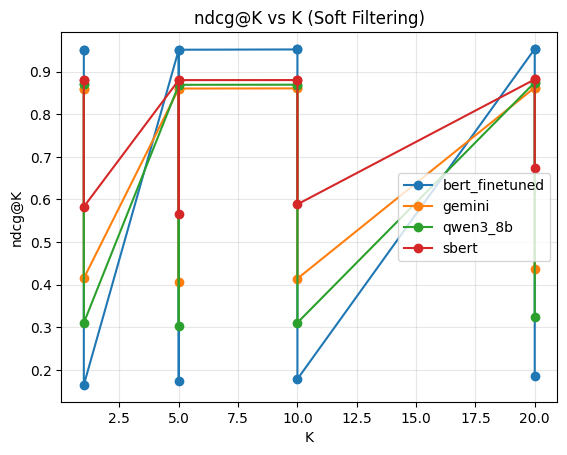

In [2]:
metric_col = "ndcg@K"

plt.figure()
for emb, g in df.groupby("embedding"):
    g2 = g.sort_values("K")
    plt.plot(g2["K"], g2[metric_col], marker="o", label=emb)

plt.xlabel("K")
plt.ylabel(metric_col)
plt.title(f"{metric_col} vs K (Soft Filtering)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

2) Line Plot —  Precision@K for embeddings

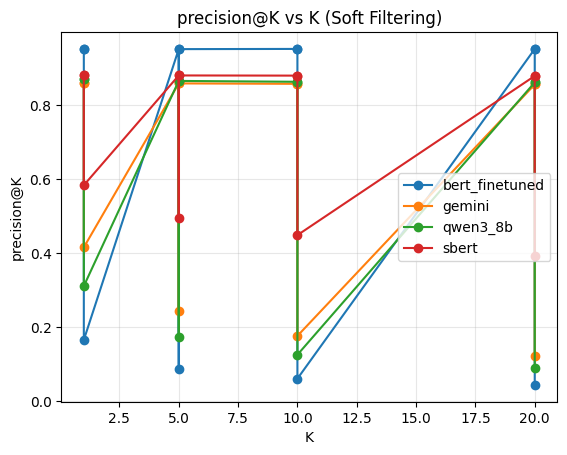

In [3]:
metric_col = "precision@K"

plt.figure()
for emb, g in df.groupby("embedding"):
    g2 = g.sort_values("K")
    plt.plot(g2["K"], g2[metric_col], marker="o", label=emb)

plt.xlabel("K")
plt.ylabel(metric_col)
plt.title(f"{metric_col} vs K (Soft Filtering)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

3) Grouped Bar Chart 

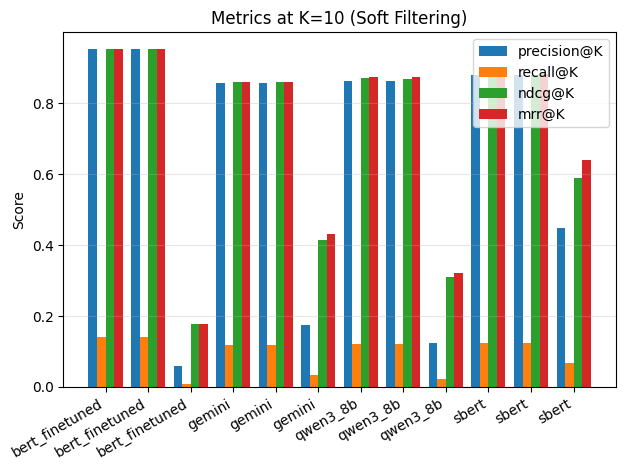

In [4]:
K_FIXED = 10
metrics = ["precision@K", "recall@K", "ndcg@K", "mrr@K"]

sub = df[df["K"] == K_FIXED].copy()
sub = sub.sort_values("embedding")

embeddings = sub["embedding"].tolist()
x = np.arange(len(embeddings))
bar_w = 0.2

plt.figure()
for i, m in enumerate(metrics):
    plt.bar(x + (i - (len(metrics)-1)/2)*bar_w, sub[m].values, width=bar_w, label=m)

plt.xticks(x, embeddings, rotation=30, ha="right")
plt.ylabel("Score")
plt.title(f"Metrics at K={K_FIXED} (Soft Filtering)")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

4) Heatmap — embedding × K

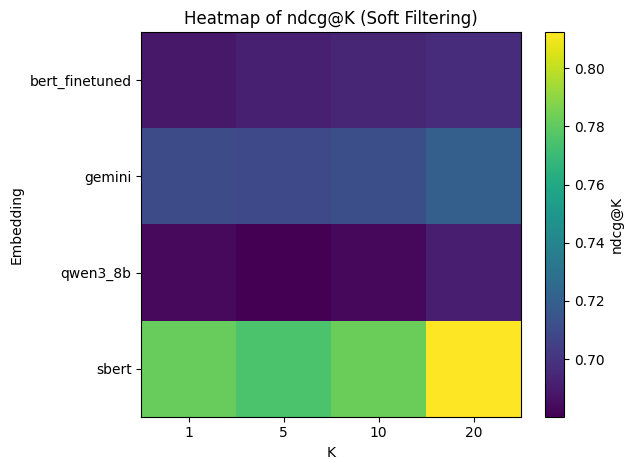

In [5]:
metric_col = "ndcg@K"

pivot = df.pivot_table(index="embedding", columns="K", values=metric_col, aggfunc="mean")
pivot = pivot.sort_index()
Ks = pivot.columns.tolist()
embs = pivot.index.tolist()
Z = pivot.values

plt.figure()
plt.imshow(Z, aspect="auto")
plt.xticks(np.arange(len(Ks)), Ks)
plt.yticks(np.arange(len(embs)), embs)
plt.xlabel("K")
plt.ylabel("Embedding")
plt.title(f"Heatmap of {metric_col} (Soft Filtering)")
plt.colorbar(label=metric_col)
plt.tight_layout()
plt.show()

5) Radar Chart 

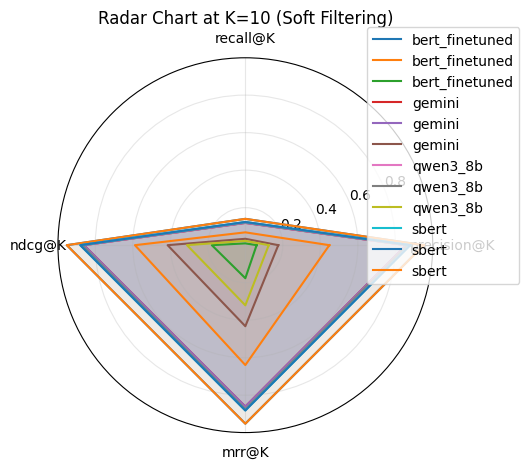

In [6]:
K_FIXED = 10
metrics = ["precision@K", "recall@K", "ndcg@K", "mrr@K"]

sub = df[df["K"] == K_FIXED].copy().sort_values("embedding")

labels = metrics
num_vars = len(labels)
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the loop

plt.figure()
ax = plt.subplot(111, polar=True)

for _, row in sub.iterrows():
    values = [float(row[m]) for m in metrics]
    values += values[:1]  # close
    ax.plot(angles, values, label=row["embedding"])
    ax.fill(angles, values, alpha=0.08)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_title(f"Radar Chart at K={K_FIXED} (Soft Filtering)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()

integrating charts

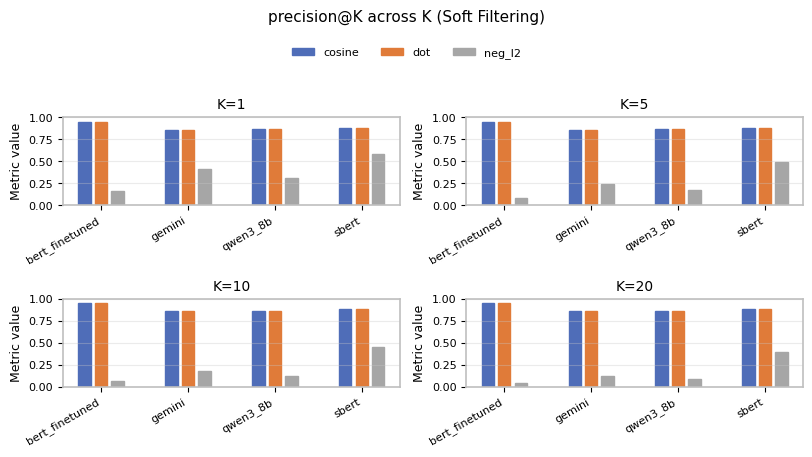

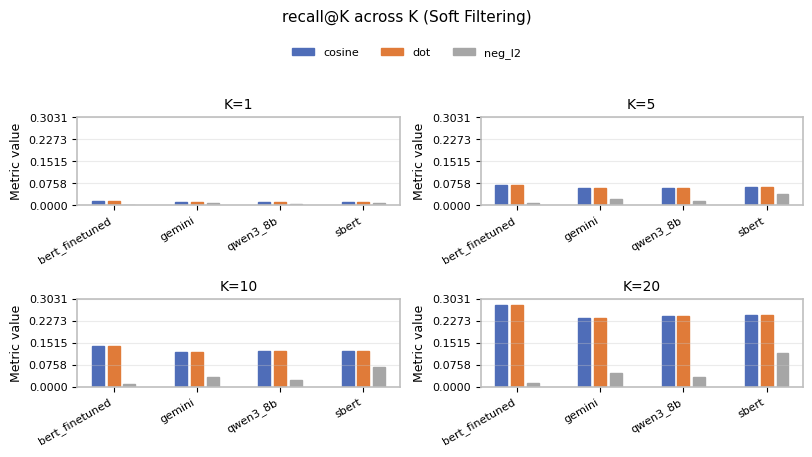

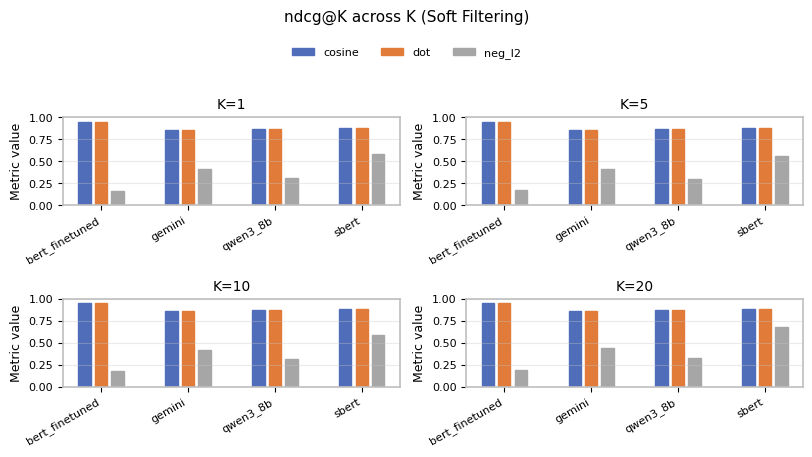

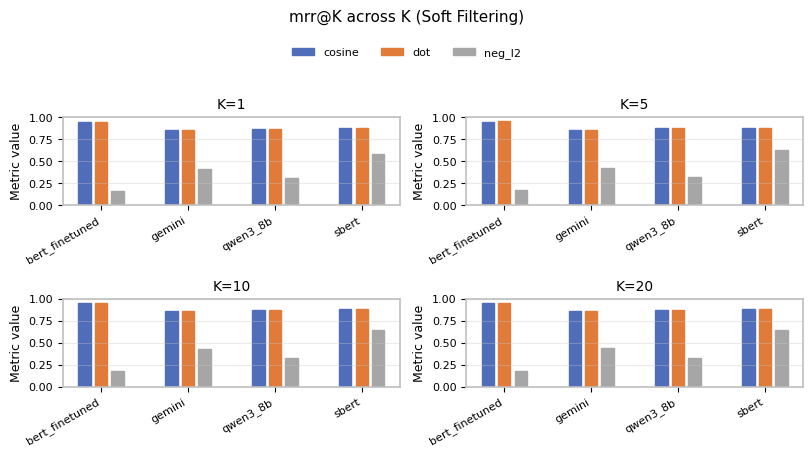

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULT_XLSX = "soft_filtering_results.xlsx"
df = pd.read_excel(RESULT_XLSX, sheet_name="Summary", engine="openpyxl")

df = df[df["method"].astype(str).str.contains("soft_filter", case=False, na=False)].copy()
df["K"] = df["K"].astype(int)

K_LIST = [1, 5, 10, 20]
df = df[df["K"].isin(K_LIST)]

score_cols = ["precision@K", "recall@K", "ndcg@K", "mrr@K"]
colors = ["#4F6DB8", "#E07B39", "#A6A6A6"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#BFBFBF",
    "axes.linewidth": 1.2,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

for score_col in score_cols:
    fig, axes = plt.subplots(2, 2, figsize=(8.2, 4.6))
    axes = axes.flatten()
    fig.suptitle(f"{score_col} across K (Soft Filtering)", fontsize=11, y=0.98)

    legend_handles = None
    legend_labels = None

    vals_all = df[score_col].astype(float).values
    y_min = 0
    y_max = min(1.0, np.max(vals_all) * 1.08)

    for idx, K_FIXED in enumerate(K_LIST):
        ax = axes[idx]
        sub = df[df["K"] == K_FIXED]

        pivot = sub.pivot_table(
            index="embedding",
            columns="metric",
            values=score_col,
            aggfunc="mean"
        ).sort_index()

        embeddings = pivot.index.tolist()
        sim_metrics = pivot.columns.tolist()

        # 👇 فاصله کمتر بین گروه‌ها
        x = np.arange(len(embeddings)) * 0.95
        bar_w = 0.18

        for j, met in enumerate(sim_metrics):
            ax.bar(
                x + (j - (len(sim_metrics)-1)/2)*bar_w,
                pivot[met].values,
                width=bar_w * 0.75,
                color=colors[j % len(colors)],
                edgecolor=colors[j % len(colors)],
                label=str(met)
            )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        ax.set_title(f"K={K_FIXED}")
        ax.set_xticks(x)
        ax.set_xticklabels(embeddings, rotation=30, ha="right")  # 👈 اریب

        ax.set_ylabel("Metric value")
        ax.set_ylim(y_min, y_max)
        ax.set_yticks(np.linspace(y_min, y_max, 5))

        ax.grid(True, axis="y", linewidth=0.8, alpha=0.35)
        ax.grid(False, axis="x")

    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        ncol=len(legend_labels),
        frameon=False,
        bbox_to_anchor=(0.5, 0.92)
    )

    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()

C:\Users\Alire\AppData\Local\Temp\ipykernel_49368\3070801352.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95], pad=0.25)


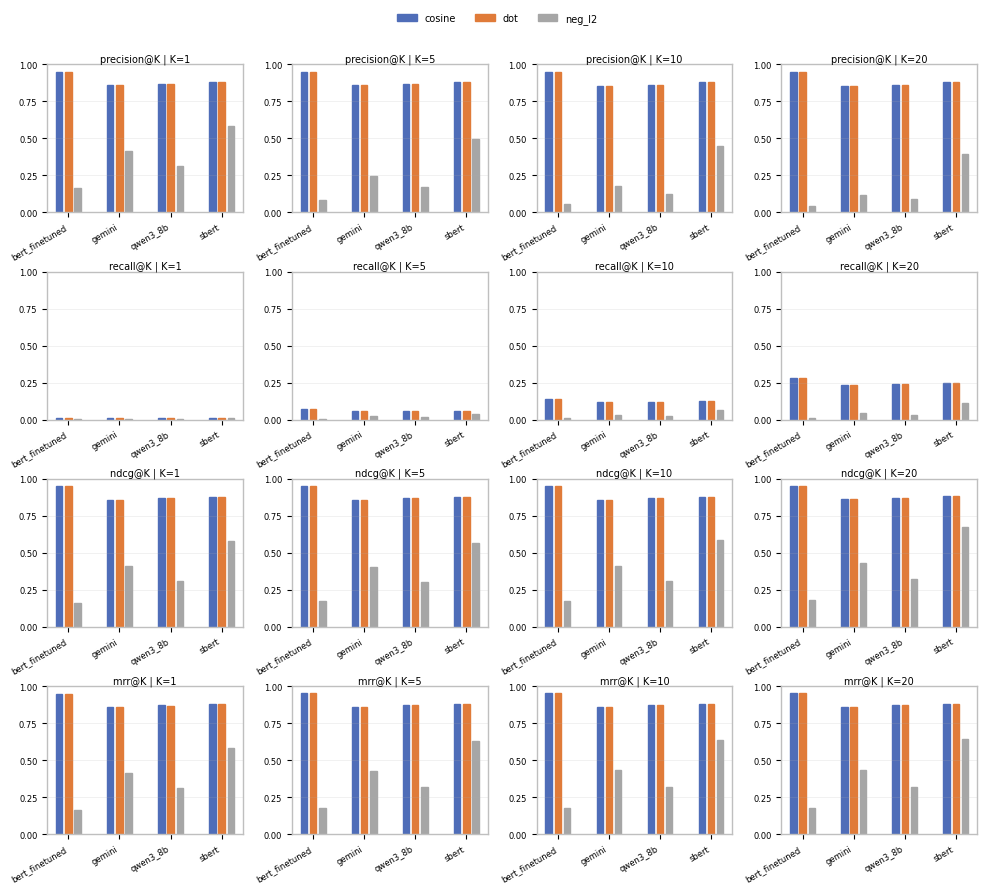

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------- Load data ----------
RESULT_XLSX = "soft_filtering_results.xlsx"
df = pd.read_excel(RESULT_XLSX, sheet_name="Summary", engine="openpyxl")

df = df[df["method"].astype(str).str.contains("soft_filter", case=False, na=False)].copy()
df["K"] = df["K"].astype(int)

K_LIST = [1, 5, 10, 20]
df = df[df["K"].isin(K_LIST)]

score_cols = ["precision@K", "recall@K", "ndcg@K", "mrr@K"]
colors = ["#4F6DB8", "#E07B39", "#A6A6A6"]  # blue, orange, gray

# --------- Style ----------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#BFBFBF",
    "axes.linewidth": 1.0,
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 7
})

# --------- Create compact 4x4 grid ----------
fig, axes = plt.subplots(
    4, 4,
    figsize=(12, 10),
    gridspec_kw={"hspace": 0.40, "wspace": 0.25}  # 👈 very compact
)

# fig.suptitle("Soft Filtering Performance (All Metrics and K Values)", fontsize=12, y=0.965)

legend_handles, legend_labels = None, None

# Optional: fixed y-range for all (0..1). You can change for recall-only if desired.
ymin, ymax = 0.0, 1.0
yticks = np.linspace(0, 1, 5)

for row, score_col in enumerate(score_cols):
    for col, K_FIXED in enumerate(K_LIST):
        ax = axes[row, col]
        sub = df[df["K"] == K_FIXED]

        pivot = sub.pivot_table(
            index="embedding",
            columns="metric",
            values=score_col,
            aggfunc="mean"
        ).sort_index()

        embeddings = pivot.index.tolist()
        sim_metrics = pivot.columns.tolist()

        x = np.arange(len(embeddings))
        bar_w = 0.18

        for j, met in enumerate(sim_metrics):
            ax.bar(
                x + (j - (len(sim_metrics) - 1) / 2) * bar_w,
                pivot[met].values,
                width=bar_w * 0.70,
                color=colors[j % len(colors)],
                edgecolor=colors[j % len(colors)],
                label=str(met)
            )

        # capture legend once
        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        ax.set_title(f"{score_col} | K={K_FIXED}", pad=2)

        ax.set_xticks(x)
        ax.set_xticklabels(embeddings, rotation=30, ha="right")

        ax.set_ylim(ymin, ymax)
        ax.set_yticks(yticks)

        ax.grid(True, axis="y", linewidth=0.5, alpha=0.25)
        ax.grid(False, axis="x")

# --------- Shared legend (close to title) ----------
fig.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
    bbox_to_anchor=(0.5, 0.94)
)

# --------- Tighten layout further ----------
plt.tight_layout(rect=[0, 0, 1, 0.95], pad=0.25)
plt.show()

In [ ]:
# path and name of the output file
FIG_NAME = "Soft_Filtering_Search_Performanc_HQ.png"

fig.savefig(
    FIG_NAME,
    dpi=600,          
    bbox_inches="tight"
)

print("Figure saved as:", FIG_NAME)

✅ Figure saved as: Soft_Filtering_Search_Performanc_HQ.png


only cosine similarity, and NDGC metric

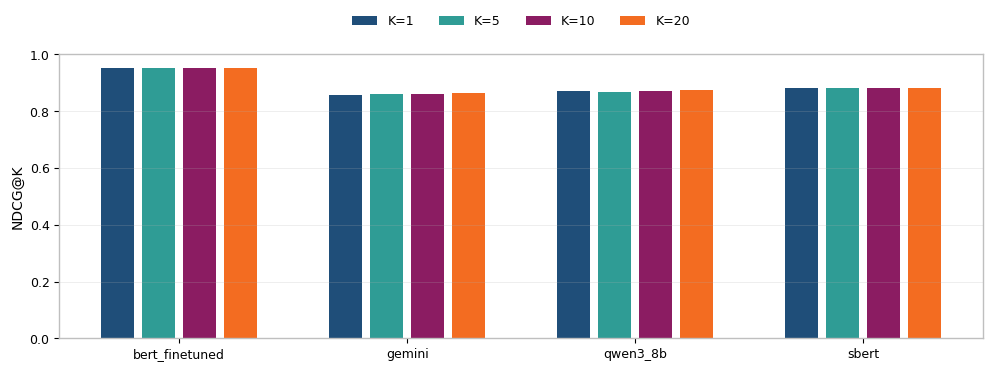

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

XLSX = "soft_filtering_results.xlsx"  
SHEET = "Summary"

K_LIST = [1, 5, 10, 20]

df = pd.read_excel(XLSX, sheet_name=SHEET, engine="openpyxl")

# فقط cosine
df = df[df["metric"].astype(str).str.lower() == "cosine"].copy()
df["K"] = df["K"].astype(int)
df = df[df["K"].isin(K_LIST)]

# pivot: rows=embedding, cols=K, value=ndcg@K
pivot = df.pivot_table(index="embedding", columns="K", values="ndcg@K", aggfunc="mean").sort_index()

embeddings = pivot.index.tolist()
x = np.arange(len(embeddings))
bar_w = 0.18

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#BFBFBF",
    "axes.linewidth": 1.0,
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

fig, ax = plt.subplots(figsize=(10, 3.8))
colors = ["#1f4e79", "#2f9c95", "#8b1c62", "#f36c21"]
for j, K in enumerate(K_LIST):
    ax.bar(
        x + (j - (len(K_LIST) - 1)/2) * bar_w,
        pivot[K].values,
        width=bar_w * 0.8,
        color=colors[j % len(colors)],
        label=f"K={K}"
    )

# ax.set_title("Classifier-guided Retrieval (Top-k Soft Filtering) — NDCG@K (cosine)")
ax.set_ylabel("NDCG@K")
ax.set_xticks(x)
ax.set_xticklabels(embeddings, rotation=0, ha="center")

ax.set_ylim(0.0, 1.0)
ax.set_yticks(np.linspace(0, 1, 6))
ax.grid(True, axis="y", linewidth=0.6, alpha=0.25)
ax.legend(ncol=len(K_LIST), frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.18))

plt.tight_layout()
plt.show()

In [ ]:
FIG_NAME = "Classifier_guided_Retrieval_NDCG_cosine.png"

fig.savefig(
    FIG_NAME,
    dpi=600,              #
    bbox_inches="tight"
)

print("Figure saved as:", FIG_NAME)

✅ Figure saved as: Classifier_guided_Retrieval_NDCG_cosine.png


recall

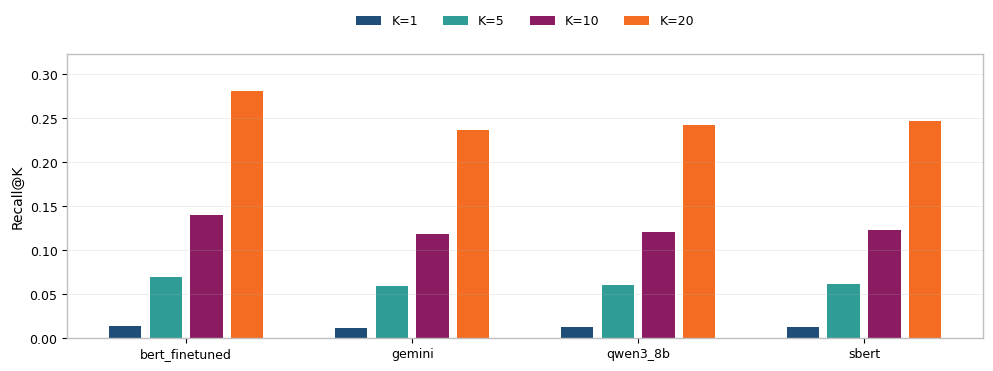

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

XLSX = "soft_filtering_results.xlsx"
SHEET = "Summary"

K_LIST = [1, 5, 10, 20]

df = pd.read_excel(XLSX, sheet_name=SHEET, engine="openpyxl")

# فقط cosine
df = df[df["metric"].astype(str).str.lower() == "cosine"].copy()
df["K"] = df["K"].astype(int)
df = df[df["K"].isin(K_LIST)]

pivot = df.pivot_table(index="embedding", columns="K", values="recall@K", aggfunc="mean").sort_index()

embeddings = pivot.index.tolist()
x = np.arange(len(embeddings))
bar_w = 0.18

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#BFBFBF",
    "axes.linewidth": 1.0,
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

fig, ax = plt.subplots(figsize=(10, 3.8))
colors = ["#1f4e79", "#2f9c95", "#8b1c62", "#f36c21"]
for j, K in enumerate(K_LIST):
    ax.bar(
        x + (j - (len(K_LIST) - 1)/2) * bar_w,
        pivot[K].values,
        width=bar_w * 0.80,
        color=colors[j % len(colors)],
        label=f"K={K}"
    )

# ax.set_title("Classifier-guided Retrieval (Top-k Soft Filtering) — Recall@K (cosine)")
ax.set_ylabel("Recall@K")
ax.set_xticks(x)
ax.set_xticklabels(embeddings, rotation=0, ha="center")

# Recall معمولاً کوچک‌تر است؛ بازه را اتومات می‌گذاریم (ولی از 0 شروع شود)
ymax = float(np.nanmax(pivot.values))
ax.set_ylim(0.0, min(1.0, ymax * 1.15 if ymax > 0 else 1.0))
ax.grid(True, axis="y", linewidth=0.6, alpha=0.25)
ax.legend(ncol=len(K_LIST), frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.18))

plt.tight_layout()
plt.show()

In [ ]:
FIG_NAME = "Classifier_guided_Retrieval_Recall_cosine.png"

fig.savefig(
    FIG_NAME,
    dpi=600,              
    bbox_inches="tight"
)

print("Figure saved as:", FIG_NAME)

✅ Figure saved as: Classifier_guided_Retrieval_Recall_cosine.png


combine two chart in the same fig

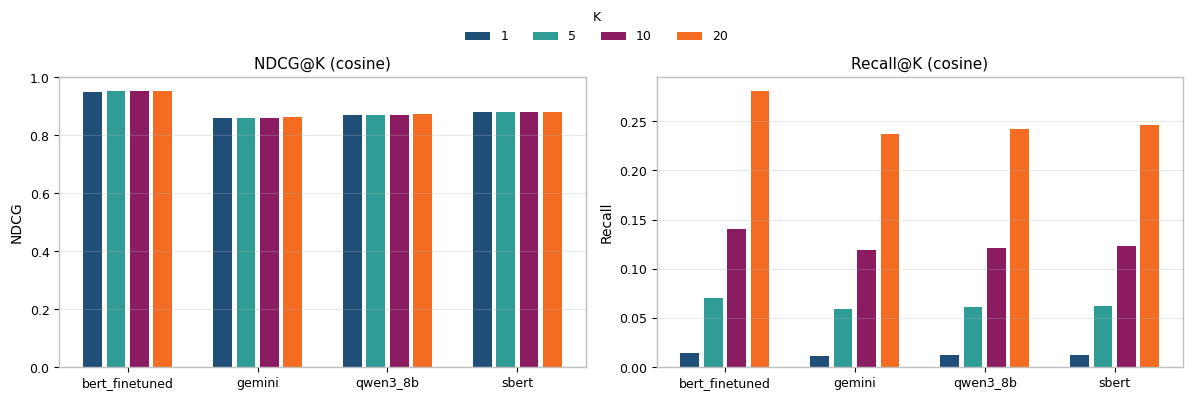

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

XLSX = "soft_filtering_results.xlsx"
SHEET = "Summary"

K_LIST = [1,5,10,20]

df = pd.read_excel(XLSX, sheet_name=SHEET)

df = df[df["metric"].str.lower()=="cosine"]

df["K"] = df["K"].astype(int)
df = df[df["K"].isin(K_LIST)]

pivot_ndcg = df.pivot_table(index="embedding",columns="K",values="ndcg@K")
pivot_recall = df.pivot_table(index="embedding",columns="K",values="recall@K")

embeddings = pivot_ndcg.index.tolist()
x = np.arange(len(embeddings))
bar_w = 0.18

colors = ["#1f4e79","#2f9c95","#8b1c62","#f36c21"]

fig, axes = plt.subplots(1,2,figsize=(12,4))

# ---------- NDCG ----------
ax = axes[0]

for j,K in enumerate(K_LIST):
    ax.bar(
        x + (j-(len(K_LIST)-1)/2)*bar_w,
        pivot_ndcg[K],
        # width=bar_w,
        width=bar_w * 0.80,
        color=colors[j],
        label=f"K={K}"
    )

ax.set_title("NDCG@K (cosine)")
ax.set_ylabel("NDCG")
ax.set_xticks(x)
ax.set_xticklabels(embeddings,rotation=0,ha="center")
ax.set_ylim(0,1)
ax.grid(axis="y",alpha=0.3)

# ---------- Recall ----------
ax = axes[1]

for j,K in enumerate(K_LIST):
    ax.bar(
        x + (j-(len(K_LIST)-1)/2)*bar_w,
        pivot_recall[K],
        # width=bar_w,
        width=bar_w * 0.80,
        color=colors[j],
        label=f"K={K}"
    )

ax.set_title("Recall@K (cosine)")
ax.set_ylabel("Recall")
ax.set_xticks(x)
ax.set_xticklabels(embeddings,rotation=0,ha="center")
ax.grid(axis="y",alpha=0.3)

# legend مشترک
fig.legend(K_LIST, title="K", loc="upper center", ncol=4, frameon=False)

plt.tight_layout(rect=[0,0,1,0.9])
plt.show()

In [ ]:
FIG_NAME = "Classifier_guided_Retrieval_NDCG_Recall_cosine.png"

fig.savefig(
    FIG_NAME,
    dpi=600,              
    bbox_inches="tight"
)

print("Figure saved as:", FIG_NAME)

✅ Figure saved as: Classifier_guided_Retrieval_NDCG_Recall_cosine.png
